# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

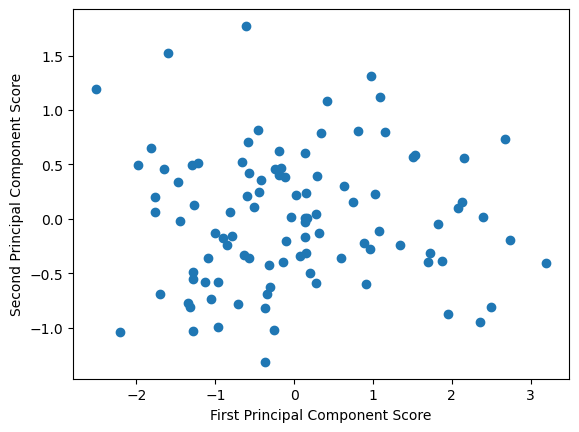

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


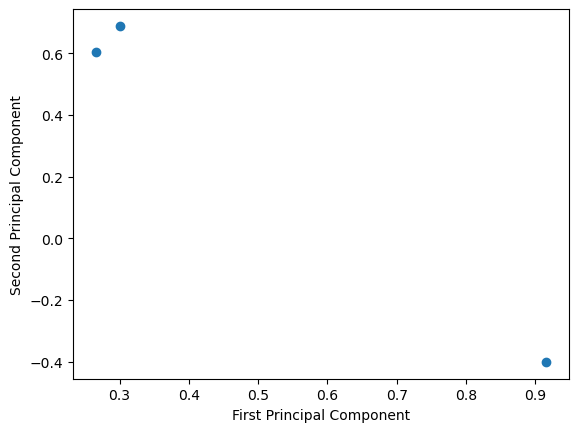

In [2]:
print(pca3.components_)
plt.scatter(pca3.components_[0], pca3.components_[1])
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.show()


1. What can be said about the three outliers in the upper-left corner of the PCA scatter plot?
 - The three outliers in the upper left corner have low values on the first principal component (PC1) and high values on the second principal component (PC2). This means these data points are unusual compared to the rest.

2. Are their first and second principal component scores high or low?
 - Their first principal component score is low, since they are on the left side of the x-axis.

3. What does that tell you about their values in series_1, series_2, and series_3?
 - The second principal component is dominated by series_3, so a high PC2 score means these points have high values in series_3. Since their PC1 score is low, and PC1 reflects a combination of all three series, we can infer that series_1 and series_2 are relatively low.

4. What can you say about series_3?
 - We can say these outliers have unusually high values in series_3, which is why they are located high along the second principal component.

5. Why is it hard to say much about series_1 and series_2 individually?
 - series_1 and series_2 are strongly positively correlated, as series_2 was created by multiplying series_1 by a small random noise. Because they vary together, PCA can't distinguish between them effectively, so it's hard to separate their contributions.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

### Dataset used:

https://www.kaggle.com/datasets/asaniczka/52000-animation-movie-details-dataset-2024

In [3]:
%pip install kagglehub

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("asaniczka/52000-animation-movie-details-dataset-2024")
csv_file_path = os.path.join(path, "animation_movies.csv")
df = pd.read_csv(csv_file_path)
print(df.info())

# Select numeric features
df_selected = df[['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']].dropna()
df_selected = df_selected[df_selected['budget'] > 0]


Note: you may need to restart the kernel to use updated packages.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51945 entries, 0 to 51944
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    51945 non-null  int64  
 1   title                 51944 non-null  object 
 2   vote_average          51945 non-null  float64
 3   vote_count            51945 non-null  int64  
 4   status                51945 non-null  object 
 5   release_date          49808 non-null  object 
 6   revenue               51945 non-null  int64  
 7   runtime               51945 non-null  int64  
 8   adult                 51945 non-null  bool   
 9   backdrop_path         15835 non-null  object 
 10  budget                51945 non-null  int64  
 11  homepage              8253 non-null   object 
 12  imdb_id               29552 non-null  object 
 13  original_language     51945 non-null  object 
 14  orig

 Select Numeric Features for Multivariate Analysis

Heatmap

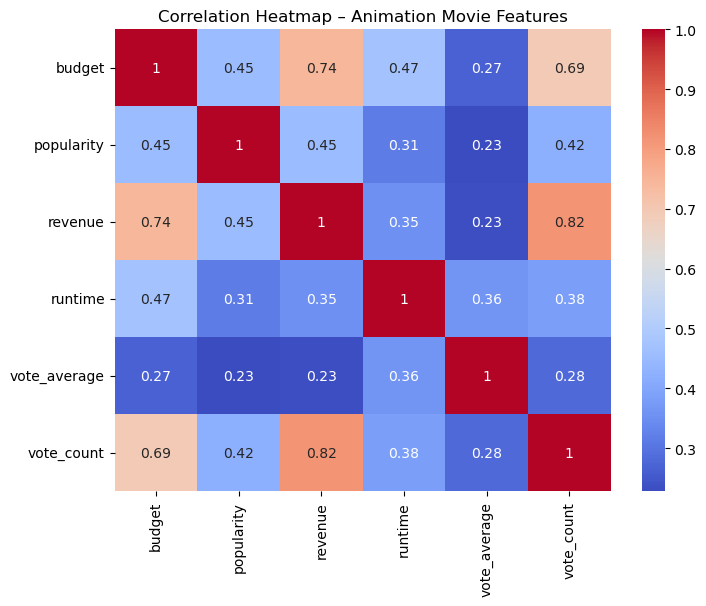

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_selected.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap – Animation Movie Features")
plt.show()

Bubble Plot

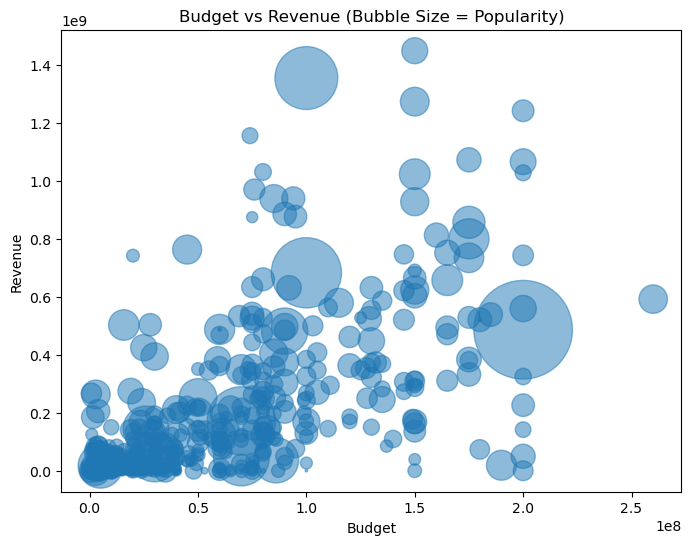

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(df_selected['budget'], df_selected['revenue'],
            s=df_selected['popularity'] * 5, alpha=0.5)
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue (Bubble Size = Popularity)")
plt.show()



PCA (Principal Component Analysis)

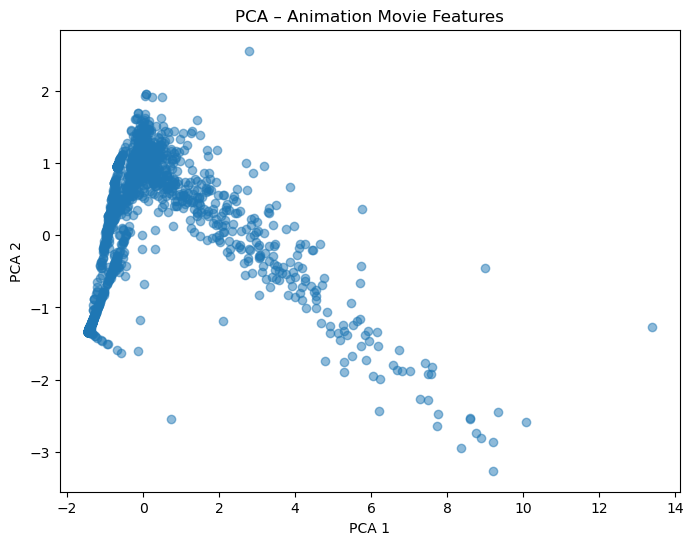

Explained variance ratio: [0.54335764 0.16172704]


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(df_selected)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA – Animation Movie Features")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

X = df_selected[['budget', 'popularity', 'vote_average']]
y = df_selected['revenue']

model = LinearRegression().fit(X, y)
print("Linear Regression R² Score:", model.score(X, y))


Linear Regression R² Score: 0.5717438629168498


### Conclusions from Multivariate Analysis on the Animation Movie Dataset
Using the 52,000-animation-movie dataset from Kaggle, I performed multivariate analysis to explore relationships between key numerical features such as budget, revenue, popularity, and vote_average.

Heatmap analysis showed a strong positive correlation between budget and revenue, suggesting that higher-budget films tend to earn more money. popularity and vote_count also had moderate correlations with revenue.

The bubble plot (budget vs. revenue with bubble size based on popularity) revealed that while higher-budget movies usually make more money, some outliers like low-budget, high-revenue films exist. These could represent surprise hits or viral animations.

PCA reduced the feature space from six dimensions to two. The first component captured most of the variation in size-related features (budget, revenue, popularity), while the second component picked up smaller variations like vote_average and runtime. This dimensionality reduction makes it easier to visualize the overall structure of the data.

In the linear regression model, I predicted revenue using budget, popularity, and vote_average. The R² score indicated that these features explain a good portion of the variance in revenue, though not all. This suggests there are other unmeasured factors influencing movie earnings (like brand value, release date, or marketing).

Overall, the dataset is rich and useful for multivariate analysis. PCA helped simplify complex relationships, and the linear regression confirmed that budget and popularity are key drivers of financial success in animation films.



# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

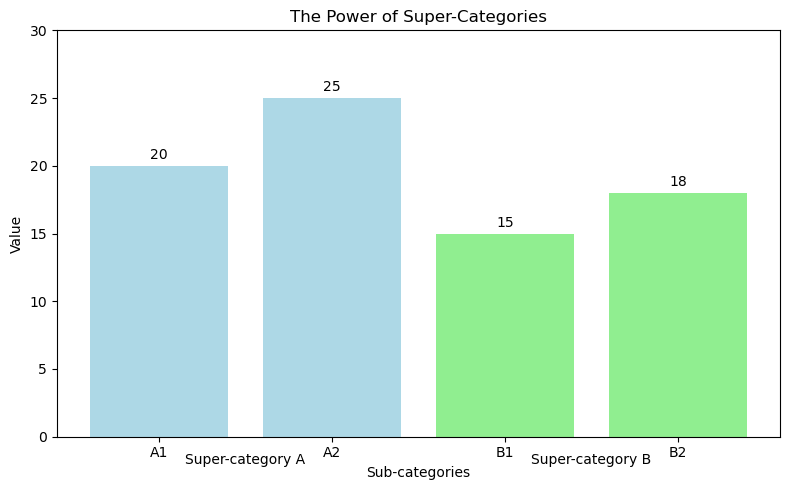

In [8]:
categories = ['A1', 'A2', 'B1', 'B2']
values = [20, 25, 15, 18]
colors = ['lightblue', 'lightblue', 'lightgreen', 'lightgreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, values, color=colors)

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}', ha='center')

# Title and labels
plt.title("The Power of Super-Categories")
plt.xlabel("Sub-categories")
plt.ylabel("Value")

# Grouping labels
plt.text(0.5, -2, 'Super-category A', ha='center')
plt.text(2.5, -2, 'Super-category B', ha='center')
plt.ylim(0, max(values) + 5)
plt.tight_layout()
plt.show()


I chose to recreate the “Power of Super-Categories” chart from Storytelling With Data (page 136).
This chart uses bar groups and color coding to emphasize how related sub-categories (like A1 and A2) belong to broader groups (like Super-category A).

This visualization helps make comparisons within and across categories more intuitive. For example, we can see at a glance that A2 is the highest, B1 the lowest, and that Group A performs slightly better than Group B.

I recreated this chart in Python using sample data and simple bar() plots. I used different colors to distinguish the two super-categories and labeled sub-category values directly on top of the bars for clarity.